In [92]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import glob
import h5py
from tqdm import tqdm
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [93]:
# Load Exp Data
def load_ExpData(file_, idx_str_):
    
    # Open hdf5 file
    with h5py.File(file_, "r") as dataset:

        # Data
        return dict(freq_comb=np.asarray(dataset[idx_str_]["freq comb"]),
                    freq_pump=np.asarray(dataset[idx_str_]["freq pumps"]),
                    pump_pwr_data=np.asarray(dataset[idx_str_]["pump pwr sweep"]),
                    pump_phase_data=np.asarray(dataset[idx_str_]["pump phase sweep"]),
                    df=np.asarray(dataset[idx_str_]["df"]),
                    USB=np.asarray(dataset[idx_str_]["USB"]),
                    )

In [94]:
folder = "/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/I:/LKiPA-Data/2026-03/Scattering"

# Get all HDF5 files in the folder
files = glob.glob(os.path.join(folder, "*.hdf5"))

# Pick the most recently modified one
file = max(files, key=os.path.getmtime)

print("Selected file:", file)

# Extract the run name automatically
run = os.path.basename(file).replace(".hdf5", "")
print("Run:", run)

usb = load_ExpData(
    file_ = file,
    idx_str_= run
    )['USB']
resonance=np.array(usb)

freqs = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_comb']


# Attributes for saving figures
modes = int(len(freqs))         # NUMBER OF MODES
print('Modes = ' + str(modes))

p_amp = int(                    # PUMP POWER
    load_ExpData(
    file_ = file,
    idx_str_= run
    )['pump_pwr_data'] * 100
)
print('Pump Power = ' + str(p_amp))

fp = load_ExpData(                    # PUMP POWER
    file_ = file,
    idx_str_= run
    )['freq_pump'] / 1e9
print('Pump Frequency  = ' + str(fp) + 'GHz')
fp = int(fp * 1e6)

df = int(load_ExpData(                    # PUMP POWER
    file_ = file,
    idx_str_= run
    )['df'] // 1e3
)
print('df = ' + str(df) + 'kHz')

Selected file: /home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/I:/LKiPA-Data/2026-03/Scattering/2026-03-13_10_46_02.hdf5
Run: 2026-03-13_10_46_02
Modes = 31
Pump Power = 25
Pump Frequency  = 8.8554GHz
df = 2kHz


(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0))


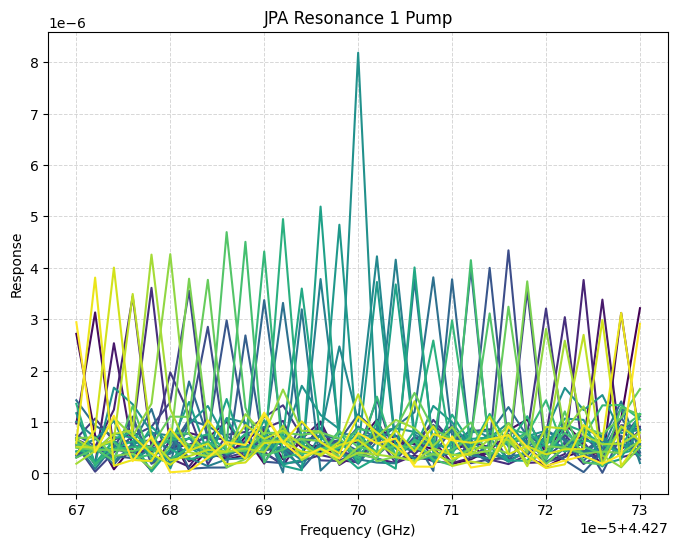

In [95]:
fig, ax = plt.subplots(figsize=(8,6))

# Plot

# Colormap and normalization
cmap = cm.viridis
norm = mcolors.Normalize(vmin=freqs[0], vmax=freqs[-1])

# Plotting
print(cmap(norm(0)))
for i in range(len(freqs)):
    colors = cmap(norm(freqs[i]))
    ax.plot(freqs/1e9,
            np.abs(usb[i]), 
            color = colors,
            )

ax.set_title(
    f'JPA Resonance 1 Pump'
    )   

# Additional
ax.grid(ls='--', lw=0.7, alpha=0.5)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Response')

# Save plot
plt.show()

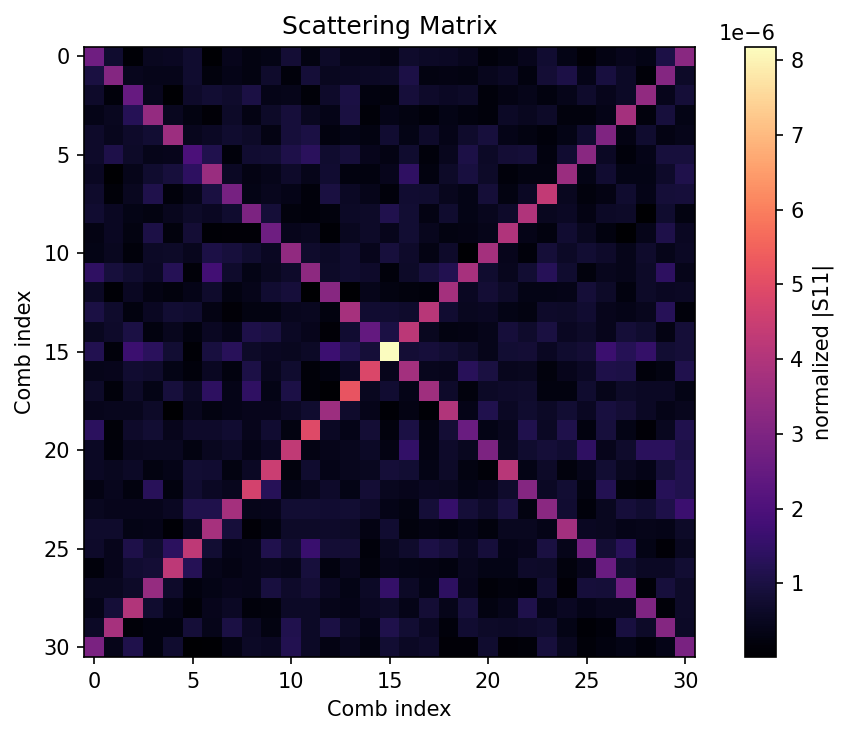

In [96]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

im = ax.imshow(
    np.abs(resonance), # / np.max(np.abs(resonance)), 
    aspect='equal', 
    cmap='magma', 
    origin='upper',
#    vmax=1e-6,
    )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("normalized |S11|")

ax.set_xlabel("Comb index")
ax.set_ylabel("Comb index")
ax.set_title("Scattering Matrix")

plt.tight_layout()
fig.savefig(
    fname= f'Figures/Scattering/LKIPA-Scat-modes={modes}-df={df}-dcb=05-pump_amp={p_amp}-pump_freq={fp}-signal_amp=003-run={run}', 
    dpi=300,
    )
plt.show()